# NBA Research
---
The goal is to first engineer some predictive features, then filter features out based on importance and redundancy.

Namely, we want to mimic the following features:
```
diff_massey_SAG
diff_massey_POM
diff_massey_WLK
diff_seed_num
diff_massey_DOL
diff_massey_PMW
diff_consensus_rank
diff_massey_MOR
diff_massey_RPI
diff_massey_COL
diff_kg_scoring_margin
diff_kg_wins
diff_kg_margin_last10_delta
diff_kg_win_pct
diff_massey_BPI
diff_kg_losses
diff_path_best_opp_seed
diff_kg_net_strong_margin
diff_path_games_played
```
After engineering them, we will run them through our pipeline.

In [ ]:
import pandas as pd
import requests
import time
from nba_api.stats.endpoints import leaguegamefinder

# --- 1. DISCOVER NBA STATS CODES ---
def get_nba_historical_codes():
    print("🚀 Fetching all historical NBA team codes...")
    # This captures every team tricode appearing in a game record since 1946
    finder = leaguegamefinder.LeagueGameFinder(league_id_nullable='00')
    df_nba = finder.get_data_frames()[0]
    
    # 'TEAM_ABBREVIATION' is the standard tricode in V2/V3
    nba_codes = sorted(df_nba['TEAM_ABBREVIATION'].unique().tolist())
    return nba_codes

# --- 2. DISCOVER ESPN CODES ---
def get_espn_historical_codes(start_year=1947, end_year=2026):
    """
    Samples dates across history to find all unique ESPN abbreviations.
    We sample November 15th of every year to catch relocated/rebranded teams.
    """
    espn_codes = set()
    print(f"🚀 Sampling ESPN codes from {start_year} to {end_year}...")
    
    for year in range(start_year, end_year + 1):
        # Sampling mid-November usually ensures the season is active
        date_str = f"{year}1115"
        url = f"https://site.api.espn.com/apis/site/v2/sports/basketball/nba/scoreboard?dates={date_str}"
        
        try:
            resp = requests.get(url, timeout=10)
            data = resp.json()
            for event in data.get('events', []):
                for comp in event.get('competitions', [{}])[0].get('competitors', []):
                    code = comp['team']['abbreviation'].upper()
                    espn_codes.add(code)
            print(f"✅ Sampled {year}")
        except Exception as e:
            print(f"❌ Error in {year}: {e}")
        
        time.sleep(0.5)
        
    return sorted(list(espn_codes))

# --- EXECUTION ---
nba_list = get_nba_historical_codes()
espn_list = get_espn_historical_codes()

# Create a comparison table
all_codes = sorted(list(set(nba_list) | set(espn_list)))
comparison = []
for code in all_codes:
    comparison.append({
        "Code": code,
        "In_NBA_API": code in nba_list,
        "In_ESPN_API": code in espn_list
    })

df_compare = pd.DataFrame(comparison)
print("\n--- Team Code Cross-Reference ---")
print(df_compare)

# Save for your mapping logic
df_compare.to_csv('/Users/michaelharoon/Projects/Prediction markets/nba/data_curation/data/team_code_audit.csv', index=False)

In [1]:
import pandas as pd
from nba_api.stats.endpoints import playercareerstats
from nba_api.live.nba.endpoints import scoreboard

# 1. Fetch Nikola Jokić's Career Stats (Stats Endpoint)
# ID 203999 = Nikola Jokić
career = playercareerstats.PlayerCareerStats(player_id='203999')

# Use the 'season_totals_regular_season' dataset specifically
df_jokic = career.season_totals_regular_season.get_data_frame()

# 2. Fetch Today's Scoreboard (Live Endpoint)
# Note: Live endpoints return dictionaries; we convert them to DataFrames manually
board = scoreboard.ScoreBoard()
games_dict = board.get_dict()
games_list = games_dict['scoreboard']['games']

df_scoreboard = pd.DataFrame(games_list)

# 3. Save to CSV
print(f'player cols:\n{df_jokic.columns}')
print(f'scoreboard cols:\n{df_scoreboard.columns}')

player cols:
Index(['PLAYER_ID', 'SEASON_ID', 'LEAGUE_ID', 'TEAM_ID', 'TEAM_ABBREVIATION',
       'PLAYER_AGE', 'GP', 'GS', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A',
       'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL',
       'BLK', 'TOV', 'PF', 'PTS'],
      dtype='str')
scoreboard cols:
Index(['gameId', 'gameCode', 'gameStatus', 'gameStatusText', 'period',
       'gameClock', 'gameTimeUTC', 'gameEt', 'regulationPeriods',
       'ifNecessary', 'seriesGameNumber', 'gameLabel', 'gameSubLabel',
       'seriesText', 'seriesConference', 'poRoundDesc', 'gameSubtype',
       'isNeutral', 'homeTeam', 'awayTeam', 'gameLeaders', 'pbOdds'],
      dtype='str')


In [4]:
from nba_api.stats.endpoints import leaguegamefinder
from nba_api.stats.static import teams

# 1. Get the Team ID (e.g., for the Lakers)
nba_teams = teams.get_teams()
lakers = [team for team in nba_teams if team['abbreviation'] == 'LAL'][0]
lakers_id = lakers['id']

# 2. Fetch all games for that team for the 2025-26 season
gamefinder = leaguegamefinder.LeagueGameFinder(
    team_id_nullable=lakers_id,
    season_nullable='2025-26'
)

# 3. Convert to a Pandas DataFrame
games_df = gamefinder.get_data_frames()[0]

# Display recent results
print(f'Columns: {games_df.columns}')

Columns: Index(['SEASON_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID',
       'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'PTS', 'FGM', 'FGA', 'FG_PCT',
       'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB',
       'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PLUS_MINUS'],
      dtype='str')


In [39]:
import time
import pandas as pd
from nba_api.stats.endpoints import leaguegamefinder
from nba_api.stats.static import teams

class Timer:
    def __enter__(self): self.start = time.time(); return self
    def __exit__(self, *args): print(f"Time taken: {time.time() - self.start:.4f}s")

# 1. Profile Team Lookup (Local/Static)
with Timer() as t:
    print("Looking up Team ID...")
    nba_teams = teams.get_teams()
    lakers = [team for team in nba_teams if team['abbreviation'] == 'LAL'][0]
    lakers_id = lakers['id']

# 2. Profile API Object Creation (This is usually the bottleneck)
# Even if data is cached or fast, the object instantiation is heavy.
with Timer() as t:
    print("Instantiating LeagueGameFinder Object...")
    gamefinder = leaguegamefinder.LeagueGameFinder(
        team_id_nullable=lakers_id,
        season_nullable='2025-26'
    )

# 3. Profile DataFrame Transformation
with Timer() as t:
    print("Transforming to DataFrame...")
    games_df = gamefinder.get_data_frames()[0]

# 4. Data Inspection (Checking structure and types)
print("\n--- Object Structure ---")
print(f"Dataframe Shape: {games_df.shape}")
print(f"Memory Usage: {games_df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print("\n--- Column Types ---")
print(games_df.dtypes)


Looking up Team ID...
Time taken: 0.0007s
Instantiating LeagueGameFinder Object...
Time taken: 0.2108s
Transforming to DataFrame...
Time taken: 0.0132s

--- Object Structure ---
Dataframe Shape: (94, 28)
Memory Usage: 57.41 KB

--- Column Types ---
SEASON_ID                str
TEAM_ID                int64
TEAM_ABBREVIATION        str
TEAM_NAME                str
GAME_ID                  str
GAME_DATE                str
MATCHUP                  str
WL                       str
MIN                    int64
PTS                    int64
FGM                    int64
FGA                    int64
FG_PCT               float64
FG3M                   int64
FG3A                   int64
FG3_PCT              float64
FTM                    int64
FTA                    int64
FT_PCT               float64
OREB                   int64
DREB                   int64
REB                    int64
AST                    int64
STL                    int64
BLK                    int64
TOV                    int

In [38]:
games_df['SEASON_ID'].unique()

<StringArray>
['42025', '22025', '12025']
Length: 3, dtype: str

In [10]:
import os
import pandas as pd
import time
import random
from nba_api.stats.endpoints import leaguegamefinder, boxscoretraditionalv3
from nba_api.stats.library.http import NBAStatsHTTP

# 1. Global Setup
def patch_nba_api_headers():
    NBAStatsHTTP.default_headers = {
        'Host': 'stats.nba.com',
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:125.0) Gecko/20100101 Firefox/125.0',
        'Accept': 'application/json, text/plain, */*',
        'Accept-Language': 'en-US,en;q=0.5',
        'Referer': 'https://www.nba.com/',
        'Origin': 'https://www.nba.com',
        'Connection': 'keep-alive',
    }

patch_nba_api_headers()
DATA_DIR = "./nba_data_rosters"
os.makedirs(DATA_DIR, exist_ok=True)

# 2. Get the Master List of Game IDs
print("Fetching master game list...")
finder = leaguegamefinder.LeagueGameFinder(league_id_nullable='00')
all_games = finder.get_data_frames()[0]
unique_game_ids = all_games['GAME_ID'].unique()

# 3. The Scraping Loop with Checkpointing
def run_scraper(game_ids):
    for g_id in game_ids:
        file_path = os.path.join(DATA_DIR, f"{g_id}.csv")
        
        # SKIP if we already have this game (The Resume Logic)
        if os.path.exists(file_path):
            continue
            
        try:
            print(f"Processing Game: {g_id}")
            # NBA servers are fickle; use a long timeout
            box = boxscoretraditionalv3.BoxScoreTraditionalV3(game_id=g_id, timeout=60)
            df = box.get_data_frames()[0]
            
            if not df.empty:
                df.to_csv(file_path, index=False)
            
            # The Golden Rule: 0.6s to 1.2s jittered sleep
            time.sleep(random.uniform(0.7, 1.3))
            
        except Exception as e:
            print(f"Failed on {g_id}: {e}. Sleeping 10s and continuing...")
            time.sleep(10) # Heavy sleep on error to let the IP cool down
            continue

# Run the scraper
# To test, you can slice the list: unique_game_ids[:100]
run_scraper(unique_game_ids)

Fetching master game list...
Processing Game: 0042500107
Processing Game: 0042500137
Processing Game: 0042500117
Processing Game: 0042500106
Processing Game: 0042500176
Processing Game: 0042500136
Processing Game: 0042500116
Processing Game: 0042500126
Processing Game: 0042500166
Processing Game: 0042500175
Processing Game: 0042500135
Processing Game: 0042500105
Processing Game: 0042500125
Processing Game: 0042500155
Processing Game: 0042500115
Processing Game: 0042500165
Processing Game: 0042500144
Processing Game: 0042500104
Processing Game: 0042500134
Processing Game: 0042500174
Processing Game: 0042500114
Processing Game: 0042500154
Processing Game: 0042500164
Processing Game: 0042500143
Processing Game: 0042500103
Processing Game: 0042500124
Processing Game: 0042500153
Processing Game: 0042500113
Processing Game: 0042500173
Processing Game: 0042500123
Processing Game: 0042500163
Processing Game: 0042500133
Processing Game: 0042500102
Processing Game: 0042500142
Processing Game: 00

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import time
from nba_api.stats.endpoints import leaguegamefinder, boxscoretraditionalv3, leaguestandings
from nba_api.stats.static import teams

# 1. Setup: Get a specific Team ID (Lakers)
nba_teams = teams.get_teams()
target_team = [t for t in nba_teams if t['abbreviation'] == 'LAL'][0]
team_id = target_team['id']

print(f"--- Sampling Data for: {target_team['full_name']} ---")

# 2. Sample Game Data (Filtered by Team and Season)
# '22023' = Regular Season (2) + 2023-24 (2023)
game_finder = leaguegamefinder.LeagueGameFinder(
    team_id_nullable=team_id, 
    season_nullable='2023-24',
    season_type_nullable='Regular Season'
)
games_sample = game_finder.get_data_frames()[0]
print(f"Fetched {len(games_sample)} games for the sample.")

# 3. Sample Team Performance (Current Standings)
standings = leaguestandings.LeagueStandings(season='2023-24')
standings_df = standings.get_data_frames()[0]
team_stats_sample = standings_df[standings_df['TeamID'] == team_id]
print(f"Team Stats Sample: {team_stats_sample[['TeamName', 'Record', 'WinPCT']].to_string(index=False)}")

# 4. Sample Roster/Box Score (For the first game in the sample)
sample_game_id = games_sample.iloc[0]['GAME_ID']
print(f"Fetching roster for Game ID: {sample_game_id}")

box = boxscoretraditionalv3.BoxScoreTraditionalV2(game_id=sample_game_id)
roster_sample = box.get_data_frames()[0]

# Displaying 'MIN' and 'COMMENT' allows you to see who played vs who didn't (DNP)
print("\nRoster Sample (First 5 players):")
print(roster_sample[['PLAYER_NAME', 'TEAM_ABBREVIATION', 'MIN', 'COMMENT']].head())

# 5. Check Sample Size
total_bytes = games_sample.memory_usage().sum() + roster_sample.memory_usage().sum()
print(f"\nTotal sample memory usage: {total_bytes / 1024:.2f} KB")

--- Sampling Data for: Los Angeles Lakers ---
Fetched 82 games for the sample.
Team Stats Sample: TeamName Record  WinPCT
  Lakers  47-35   0.573
Fetching roster for Game ID: 0022301195


/var/folders/cx/gx6njnbj39qgss912bmvd5d40000gn/T/ipykernel_22808/2991282439.py:33: DeprecationWarning: BoxScoreTraditionalV2 is deprecated and will be removed in a future version. Please use BoxScoreTraditionalV3 instead. Data is no longer being published for BoxScoreTraditionalV2 as of the 2025-26 NBA season.
  box = boxscoretraditionalv2.BoxScoreTraditionalV2(game_id=sample_game_id)



Roster Sample (First 5 players):
        PLAYER_NAME TEAM_ABBREVIATION    MIN COMMENT
0     Rui Hachimura               LAL  34:16        
1      LeBron James               LAL  37:41        
2     Anthony Davis               LAL  32:35        
3     Austin Reaves               LAL  28:34        
4  D'Angelo Russell               LAL  37:55        

Total sample memory usage: 24.98 KB


In [11]:
import pandas as pd
from nba_api.stats import endpoints
import time

# 1. Define the endpoints you want to sample
# You can add any from your list here
sample_list = [
    'LeagueDashPlayerClutch', 
    'PlayerEstimatedMetrics', 
    'WinProbabilityPBP',
    'TeamDashboardByGeneralSplits'
]

# 2. Setup Headers (Crucial for 2026 stability)
headers = {
    'Host': 'stats.nba.com',
    'User-Agent': 'Mozilla/5.0',
    'Referer': 'https://www.nba.com/'
}

def sample_endpoints(endpoint_names):
    for name in endpoint_names:
        print(f"\n--- Sampling: {name} ---")
        try:
            # Dynamically get the class from the endpoints module
            endpoint_class = getattr(endpoints, name)
            
            # Most endpoints require at least one parameter (like LeagueID or Season)
            # We use common defaults here
            instance = endpoint_class(headers=headers, timeout=30)
            
            # Get the first dataframe available in the object
            df = instance.get_data_frames()[0]
            
            print(f"Shape: {df.shape}")
            print(f"Columns: {list(df.columns[:10])}...") # Print first 10 columns
            print(df.head(3))
            
            # Rate limiting safety
            time.sleep(1.5) 
            
        except Exception as e:
            print(f"Could not sample {name}: {e}")

if __name__ == "__main__":
    sample_endpoints(sample_list)


--- Sampling: LeagueDashPlayerClutch ---
Could not sample LeagueDashPlayerClutch: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=30)

--- Sampling: PlayerEstimatedMetrics ---
Could not sample PlayerEstimatedMetrics: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=30)

--- Sampling: WinProbabilityPBP ---
Could not sample WinProbabilityPBP: WinProbabilityPBP.__init__() missing 1 required positional argument: 'game_id'

--- Sampling: TeamDashboardByGeneralSplits ---
Could not sample TeamDashboardByGeneralSplits: TeamDashboardByGeneralSplits.__init__() missing 1 required positional argument: 'team_id'


## 📊 Dataset Overview

,Metric,Value
0,Total Games,19
1,Total Columns,269
2,File Size,0.20 MB
3,Memory Usage,0.04 MB


## 🛠 Column Types & Quality

,Dtype,Nulls,Null %
game_id,str,0,0.00
game_code,str,0,0.00
game_date,str,0,0.00
game_time_utc,str,0,0.00
game_et,str,0,0.00
...,...,...,...
away_hustle_boxOuts,int64,0,0.00
espn_event_id,str,0,0.00
espn_venue_id,str,0,0.00
capacity,float64,7,36.84


## 📅 Time Coverage

**Range:** 2026-04-30 to 2026-05-09

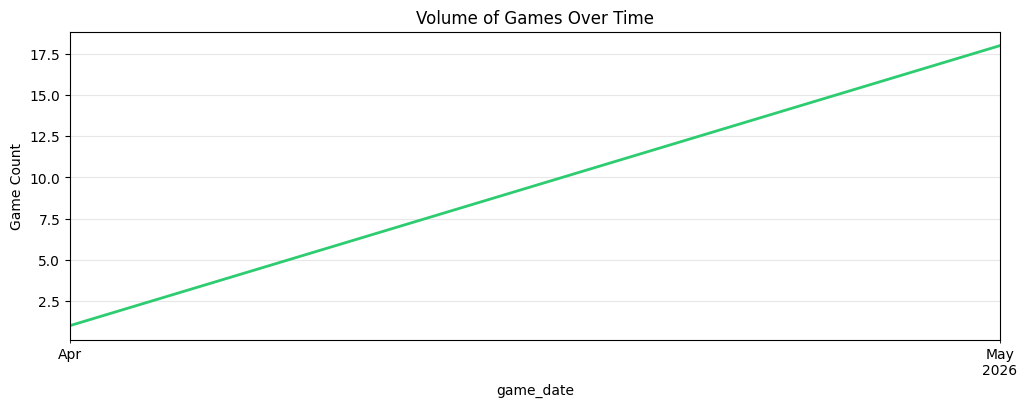

## 🔍 Latest 5 Games

,game_id,game_code,game_date,game_time_utc,game_et,game_status,game_status_text,period,game_duration,is_neutral,...,away_hustle_looseBallsRecoveredTotal,away_hustle_offensiveBoxOuts,away_hustle_defensiveBoxOuts,away_hustle_boxOutPlayerTeamRebounds,away_hustle_boxOutPlayerRebounds,away_hustle_boxOuts,espn_event_id,espn_venue_id,capacity,crowd_density
18,0042500223,20260509/OKCLAL,2026-05-09 20:30:00+00:00,2026-05-10T00:30:00Z,2026-05-09T20:30:00Z,3,Final,4,2:16,False,...,2,1,2,3,3,3,401871328,1841,19060.0,0.999843
17,0042500203,20260509/DETCLE,2026-05-09 15:00:00+00:00,2026-05-09T19:00:00Z,2026-05-09T15:00:00Z,3,Final,4,2:39,False,...,0,0,2,2,1,2,401871335,3417,20562.0,0.945044
16,0042500233,20260508/SASMIN,2026-05-08 21:30:00+00:00,2026-05-09T01:30:00Z,2026-05-08T21:30:00Z,3,Final,4,2:41,False,...,7,0,4,4,1,4,401871154,2029,19356.0,0.980471
15,0042500213,20260508/NYKPHI,2026-05-08 19:00:00+00:00,2026-05-08T23:00:00Z,2026-05-08T19:00:00Z,3,Final,4,2:34,False,...,8,2,5,7,3,9,401871161,1845,NaN,NaN
14,0042500222,20260507/LALOKC,2026-05-07 21:30:00+00:00,2026-05-08T01:30:00Z,2026-05-07T21:30:00Z,3,Final,4,2:34,False,...,1,2,4,6,6,6,401871327,2559,NaN,NaN


In [8]:
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Configuration
file_path = pathlib.Path("data_curation/data/games.parquet")

if not file_path.exists():
    display(Markdown(f"### ❌ File not found\nPath: `{file_path}`"))
else:
    # 1. Load Data
    df = pd.read_parquet(file_path)
    
    # 2. High-Level Summary
    display(Markdown("## 📊 Dataset Overview"))
    stats = pd.DataFrame({
        "Metric": ["Total Games", "Total Columns", "File Size", "Memory Usage"],
        "Value": [
            f"{len(df):,}",
            f"{len(df.columns)}",
            f"{file_path.stat().st_size / (1024*1024):.2f} MB",
            f"{df.memory_usage(deep=True).sum() / (1024*1024):.2f} MB"
        ]
    })
    display(stats)

    # 3. Column Inspection
    display(Markdown("## 🛠 Column Types & Quality"))
    quality = pd.DataFrame({
        "Dtype": df.dtypes,
        "Nulls": df.isnull().sum(),
        "Null %": (df.isnull().sum() / len(df) * 100).round(2)
    })
    display(quality)

    # 4. Temporal Distribution
    if "game_date" in df.columns:
        df["game_date"] = pd.to_datetime(df["game_date"])
        
        display(Markdown(f"## 📅 Time Coverage"))
        display(Markdown(f"**Range:** {df['game_date'].min().date()} to {df['game_date'].max().date()}"))
        
        # Plotting game frequency by month/year
        plt.figure(figsize=(12, 4))
        df.set_index("game_date").resample("ME").size().plot(
            title="Volume of Games Over Time",
            color="#2ecc71",
            lw=2
        )
        plt.ylabel("Game Count")
        plt.grid(axis='y', alpha=0.3)
        plt.show()

    # 5. Data Sample
    display(Markdown("## 🔍 Latest 5 Games"))
    display(df.sort_values("game_date", ascending=False).head())

    # 6. Team Participation
    if "home_team" in df.columns and "away_team" in df.columns:
        display(Markdown("## 🏀 Top 10 Most Frequent Teams"))
        all_teams = pd.concat([df["home_team"], df["away_team"]])
        display(all_teams.value_counts().head(10).to_frame(name="Total Games"))

In [15]:
for col in df.columns:
    print(f'{col}: {df[col].iloc[0]}')

game_id: 0042500166
game_code: 20260430/DENMIN
game_date: 2026-04-30 21:30:00+00:00
game_time_utc: 2026-05-01T01:30:00Z
game_et: 2026-04-30T21:30:00Z
game_status: 3
game_status_text: Final
period: 4
game_duration: 2:37
is_neutral: False
home_team_id: 1610612750
away_team_id: 1610612743
home_team_tricode: MIN
away_team_tricode: DEN
home_team_name: Timberwolves
away_team_name: Nuggets
home_team_city: Minnesota
away_team_city: Denver
arena_id: 61
arena_name: Target Center
arena_city: Minneapolis
arena_state: MN
arena_country: US
attendance: 18978
sellout: 1
home_wins_before: 4
home_losses_before: 2
away_wins_before: 2
away_losses_before: 4
home_q1: 29
home_q2: 28
home_q3: 25
home_q4: 28
home_score: 110
away_q1: 30
away_q2: 20
away_q3: 24
away_q4: 24
away_score: 98
home_pointsInThePaint: 64.0
away_pointsInThePaint: 40.0
home_pointsSecondChance: 20.0
away_pointsSecondChance: 4.0
home_pointsFastBreak: 13.0
away_pointsFastBreak: 7.0
home_biggestLead: 12.0
away_biggestLead: 5.0
home_leadChange

In [1]:
import pandas as pd
df = pd.read_parquet('/Users/michaelharoon/Projects/Prediction markets/nba/data_curation/data/games.parquet')
df = df[~df['game_code'].str.contains('2026')]
df

,game_id,game_code,game_date,game_time_utc,game_et,game_status,game_status_text,period,game_duration,is_neutral,...,away_hustle_looseBallsRecoveredTotal,away_hustle_offensiveBoxOuts,away_hustle_defensiveBoxOuts,away_hustle_boxOutPlayerTeamRebounds,away_hustle_boxOutPlayerRebounds,away_hustle_boxOuts,espn_event_id,espn_venue_id,capacity,crowd_density
0,0028300002,19831028/LALKCK,1983-10-28T20:00:00Z,1983-10-29T00:00:00Z,1983-10-28T20:00:00Z,3,,4,,False,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,17500.0,NaN
1,0028300006,19831028/BOSDET,1983-10-28T20:00:00Z,1983-10-29T00:00:00Z,1983-10-28T20:00:00Z,3,,4,,False,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.841875
2,0028300001,19831028/INDMIL,1983-10-28T20:00:00Z,1983-10-29T00:00:00Z,1983-10-28T20:00:00Z,3,,4,,False,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,17500.0,0.595179
3,0028300008,19831028/NYKCLE,1983-10-28T20:00:00Z,1983-10-29T00:00:00Z,1983-10-28T20:00:00Z,3,,4,,False,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,20562.0,0.312989
4,0028300005,19831028/ATLNJN,1983-10-28T20:00:00Z,1983-10-29T00:00:00Z,1983-10-28T20:00:00Z,3,,4,,False,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30978,0041000402,20110602/DALMIA,2011-06-02T21:00:00Z,2011-06-03T01:00:00Z,2011-06-02T21:00:00Z,3,Final,4,2:39,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.020561
30979,0041000403,20110605/MIADAL,2011-06-05T20:00:00Z,2011-06-06T00:00:00Z,2011-06-05T20:00:00Z,3,Final,4,2:40,False,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,1.059375
30980,0041000404,20110607/MIADAL,2011-06-07T21:00:00Z,2011-06-08T01:00:00Z,2011-06-07T21:00:00Z,3,Final,4,2:40,False,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,1.064062
30981,0041000405,20110609/MIADAL,2011-06-09T21:00:00Z,2011-06-10T01:00:00Z,2011-06-09T21:00:00Z,3,Final,4,2:39,False,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,1.064219


In [26]:
df.iloc[:,25:45].tail(10)

,home_wins_before,home_losses_before,away_wins_before,away_losses_before,home_q1,home_q2,home_q3,home_q4,home_score,away_q1,away_q2,away_q3,away_q4,away_score,home_pointsInThePaint,away_pointsInThePaint,home_pointsSecondChance,away_pointsSecondChance,home_pointsFastBreak,away_pointsFastBreak
9884,2,4,4,2,28,28,21,17,94,31,24,25,17,97,0.0,0.0,0.0,0.0,0.0,0.0
9885,3,4,4,3,27,34,25,32,118,25,25,25,27,102,0.0,0.0,0.0,0.0,0.0,0.0
9886,4,2,2,4,29,20,22,25,96,21,25,22,20,88,0.0,0.0,0.0,0.0,0.0,0.0
9887,4,3,3,4,31,26,34,32,123,26,25,29,30,110,0.0,0.0,0.0,0.0,0.0,0.0
9888,2,4,4,2,20,21,28,23,92,34,18,21,27,100,0.0,0.0,0.0,0.0,0.0,0.0
9889,2,4,4,2,29,24,31,24,108,28,31,28,24,111,0.0,0.0,0.0,0.0,0.0,0.0
9890,4,2,2,4,29,28,28,18,121,29,29,28,17,129,0.0,0.0,0.0,0.0,0.0,0.0
9891,4,2,2,4,31,30,25,25,111,27,31,23,24,105,0.0,0.0,0.0,0.0,0.0,0.0
9892,4,2,2,4,21,28,24,25,98,33,21,26,28,108,0.0,0.0,0.0,0.0,0.0,0.0
9893,2,4,4,2,28,23,28,19,98,37,19,31,12,99,0.0,0.0,0.0,0.0,0.0,0.0
